<a href="https://colab.research.google.com/github/humairasundas220/DevelopersHub_AI_ML_Internship_Advaned_Tasks/blob/main/Multimodel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

## 1. Problem Statement & Objective

**Problem:** A house's sale price depends on both its structured attributes (bedrooms, bathrooms, square footage, location) and visual characteristics that numbers alone don't capture (curb appeal, condition, architectural style, renovation quality) — information only visible in a photo of the property.

**Objective:** Build a **multimodal** regression pipeline that predicts housing prices by combining:
- **Tabular features** (bed, bath, sqft, city, etc.) — used directly.
- **Image features** — extracted from house photos using a pretrained CNN, since training a CNN from scratch on ~15K images for a downstream regression task would be data-hungry and slow; transfer learning lets us reuse features already learned from millions of general images.

These two feature sets are then **fused** (concatenated) into a single feature vector and fed into a regression model, which is evaluated using **MAE** (Mean Absolute Error — average dollar error, easy to interpret) and **RMSE** (Root Mean Squared Error — penalizes large errors more heavily, useful since expensive houses can be outliers).

**Dataset:** [House Prices and Images - SoCal](https://www.kaggle.com/datasets/ted8080/house-prices-and-images-socal) (Kaggle) — over 15,000 Southern California home listings, each with one photo and a matching row of tabular data (price and property attributes).

In [ ]:
# Loading the dataset
import kagglehub

path = kagglehub.dataset_download("ted8080/house-prices-and-images-socal")
print("Path to dataset files:", path)

100%|██████████| 369M/369M [00:04<00:00, 83.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ted8080/house-prices-and-images-socal/versions/1


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    print("  sample files:", files[:5])

/root/.cache/kagglehub/datasets/ted8080/house-prices-and-images-socal/versions/1 -> 1 files
  sample files: ['socal2.csv']
/root/.cache/kagglehub/datasets/ted8080/house-prices-and-images-socal/versions/1/socal2 -> 0 files
  sample files: []
/root/.cache/kagglehub/datasets/ted8080/house-prices-and-images-socal/versions/1/socal2/socal_pics -> 15474 files
  sample files: ['842.jpg', '5196.jpg', '14430.jpg', '1857.jpg', '7131.jpg']


In [ ]:
# Load and inspect the dataset
import pandas as pd

csv_path = f"{path}/socal2.csv"
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(15474, 8)


,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


In [ ]:
# Checking every image_id has a matching file
import os

image_dir = f"{path}/socal2/socal_pics"

df["image_path"] = df["image_id"].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))
df["image_exists"] = df["image_path"].apply(os.path.exists)

print("Total rows:", len(df))
print("Images found:", df["image_exists"].sum())
print("Images missing:", (~df["image_exists"]).sum())

Total rows: 15474
Images found: 15474
Images missing: 0


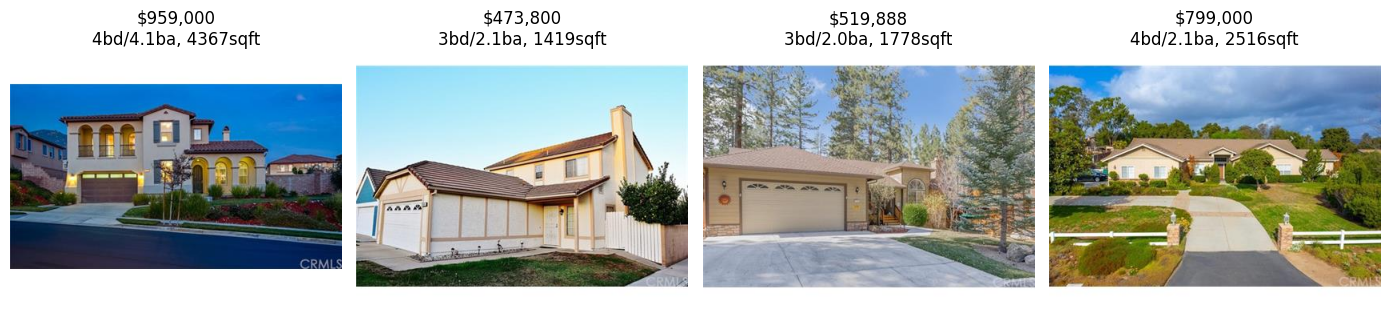

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
sample_rows = df[df["image_exists"]].sample(4, random_state=42)
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(f"${row['price']:,.0f}\n{row['bed']}bd/{row['bath']}ba, {row['sqft']}sqft")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Dataset Loading & Preprocessing

### 2.1 Loading and linking tabular data with images

The dataset consists of two parts:
- `socal2.csv` — 15,474 rows, 8 columns (`image_id`, `street`, `citi`, `n_citi`, `bed`, `bath`, `sqft`, `price`)
- `socal_pics/` — 15,474 JPEG images, one per house, named by `image_id`

Every row's `image_id` was confirmed to match exactly one image file (0 missing images out of 15,474), so no rows need to be dropped due to a missing photo. A sample of 4 houses was plotted alongside their price and attributes as a sanity check — the photos visually correspond to reasonable price points (e.g. a large 4bd/4.1ba, 4,367 sqft home at $959,000 vs. a smaller 3bd/2.1ba, 1,419 sqft home at $473,800), confirming the image-to-row linkage is correct.

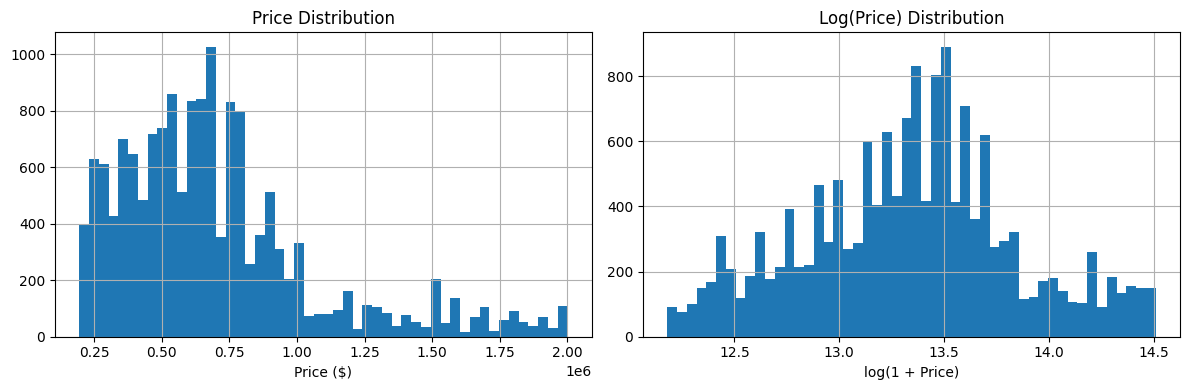

In [ ]:
# EDA on tabular data
df[["bed", "bath", "sqft", "price"]].describe()
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["price"].hist(bins=50, ax=axes[0])
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price ($)")

import numpy as np
np.log1p(df["price"]).hist(bins=50, ax=axes[1])
axes[1].set_title("Log(Price) Distribution")
axes[1].set_xlabel("log(1 + Price)")
plt.tight_layout()
plt.show()

In [ ]:
df[["bed", "bath", "sqft", "price"]].describe()

,bed,bath,sqft,price
count,15474.000000,15474.000000,15474.000000,1.547400e+04
mean,3.506398,2.453251,2173.913209,7.031209e+05
std,1.034838,0.958742,1025.339617,3.769762e+05
min,1.000000,0.000000,280.000000,1.950000e+05
25%,3.000000,2.000000,1426.000000,4.450000e+05
50%,3.000000,2.100000,1951.000000,6.390000e+05
75%,4.000000,3.000000,2737.750000,8.349750e+05
max,12.000000,36.000000,17667.000000,2.000000e+06


### 2.2 Outlier inspection

Summary statistics reveal a few data quality concerns:
- `bath` ranges up to **36**, which is not physically realistic for a residential property and is very likely a data-entry error.
- `price` is bounded between exactly $195,000 and $2,000,000 — both round numbers, suggesting the dataset was pre-filtered to this range by its creator rather than reflecting a genuine data issue.
- `sqft` reaches up to 17,667 — plausible for a large estate, but worth checking whether it corresponds to the same row as the `bath=36` anomaly.

Rows with clearly erroneous values will be removed before training, since a handful of bad rows can disproportionately distort both the tabular model and the image feature fusion.

In [ ]:
# Check the suspicious row(s)
df[df["bath"] > 10]

,image_id,street,citi,n_citi,bed,bath,sqft,price,image_path,image_exists
714,714,45439 Gingham Avenue,"Lancaster, CA",193,4,36.0,1229,240000,/root/.cache/kagglehub/datasets/ted8080/house-...,True
778,778,37809 Rudall Avenue,"Palmdale, CA",267,4,13.0,1836,299000,/root/.cache/kagglehub/datasets/ted8080/house-...,True
13568,13568,2555 Macleod Way,"Cambria, CA",60,11,11.2,6600,1550000,/root/.cache/kagglehub/datasets/ted8080/house-...,True


In [ ]:
# Filter and finalize the clean dataset
print("Before filtering:", len(df))
df_clean = df[df["bath"] <= 10].reset_index(drop=True)
print("After filtering:", len(df_clean))

Before filtering: 15474
After filtering: 15471


### 2.3 Removing data-entry errors

Three rows had implausible bathroom counts (36, 13, and 11.2 bathrooms in houses of 1,229–6,600 sqft — physically inconsistent with the space available) and were removed as data-entry errors. This is a negligible 0.02% of the dataset (3 of 15,474 rows), so it has no meaningful effect on the data available for training, but protects the model from being distorted by clearly erroneous values.

**Remaining dataset: 15,471 rows.**

In [ ]:
# Train-Test split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 12376
Test size: 3095


### 2.4 Train/test split

The cleaned dataset (15,471 rows) was split 80/20 into training and test sets **before** any feature extraction or scaling was performed, to avoid data leakage:
- **Training set:** 12,376 houses
- **Test set:** 3,095 houses

Image feature extraction (via a pretrained CNN) and tabular preprocessing (scaling/encoding) will be fit only on the training set, then applied to the test set — never the reverse.

In [ ]:
# CNN Image Feature Extraction
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Load ResNet50 pretrained on ImageNet, without its final classification layer
base_model = ResNet50(weights="imagenet", include_top=False, pooling="avg", input_shape=(224, 224, 3))
print(base_model.output_shape)  # should be (None, 2048) -- 2048-dim feature vector per image

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(None, 2048)


### 3.1 CNN Feature Extraction (Transfer Learning)

We use **ResNet50**, pretrained on ImageNet, as a fixed feature extractor:
- `include_top=False` removes ResNet's original 1,000-class classification head — we only keep the convolutional feature-learning layers underneath.
- `pooling="avg"` applies global average pooling to collapse the final feature maps into a single flat vector of **2,048 numbers per image**.
- No training happens here — the pretrained weights are frozen and simply used to transform each house photo into a numeric feature vector, which captures visual patterns (textures, shapes, structures) learned from millions of general images.

This turns the "unstructured" image data into a structured numeric feature set that can be concatenated directly with the tabular features.

In [ ]:
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def build_image_dataset(image_paths):
    def _load_and_preprocess(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)
        return img

    ds = tf.data.Dataset.from_tensor_slices(image_paths)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def extract_features(image_paths, model, desc=""):
    ds = build_image_dataset(image_paths)
    features = model.predict(ds, verbose=1)
    print(f"{desc} features shape:", features.shape)
    return features

train_image_features = extract_features(train_df["image_path"].values, base_model, desc="Train")
test_image_features = extract_features(test_df["image_path"].values, base_model, desc="Test")


np.save("train_image_features.npy", train_image_features)
np.save("test_image_features.npy", test_image_features)
print("Saved features to disk.")

387/387 ━━━━━━━━━━━━━━━━━━━━ 52s 113ms/step
Train features shape: (12376, 2048)
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step
Test features shape: (3095, 2048)
Saved features to disk.


### 3.2 Extracting features for the full dataset

Using a T4 GPU runtime, ResNet50 features were extracted for all images in ~65 seconds total:
- **Training set:** (12,376, 2,048) — one 2,048-dimensional feature vector per house image
- **Test set:** (3,095, 2,048)

Features were saved to disk (`train_image_features.npy`, `test_image_features.npy`) so this expensive step never needs to be repeated if the session restarts.

In [ ]:
# Preprocess Tabular features
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = ["bed", "bath", "sqft"]
# fit only on train
# Scale numeric features

num_scaler = StandardScaler()
train_numeric = num_scaler.fit_transform(train_df[numeric_cols])
test_numeric = num_scaler.transform(test_df[numeric_cols])

# One-hot encode city
city_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_city = city_encoder.fit_transform(train_df[["citi"]])
test_city = city_encoder.transform(test_df[["citi"]])

print("Numeric features shape:", train_numeric.shape, test_numeric.shape)
print("City one-hot shape:", train_city.shape, test_city.shape)
print("Number of unique cities:", len(city_encoder.categories_[0]))

Numeric features shape: (12376, 3) (3095, 3)
City one-hot shape: (12376, 411) (3095, 411)
Number of unique cities: 411


### 2.5 Tabular preprocessing

- **Numeric features** (`bed`, `bath`, `sqft`) were standardized using `StandardScaler`, fit only on the training set.
- **`citi`** (city name) was one-hot encoded, fit only on the training set, with `handle_unknown="ignore"` so any city appearing only in the test set won't break the encoder. This dataset spans **411 unique cities** across Southern California, so this produces a 411-dimensional one-hot block — notably wider than the 3 numeric features, but still smaller than the 2,048-dimensional image feature vector.

Resulting tabular feature shapes: (12,376, 3) numeric + (12,376, 411) city one-hot for training, and (3,095, 3) + (3,095, 411) for test.

In [ ]:
# Feature Fusion
X_train_fused = np.hstack([train_image_features, train_numeric, train_city])
X_test_fused = np.hstack([test_image_features, test_numeric, test_city])

print("Fused train shape:", X_train_fused.shape)
print("Fused test shape:", X_test_fused.shape)

# Target: log-transform price (since we saw it's right-skewed earlier)
y_train = np.log1p(train_df["price"].values)
y_test = np.log1p(test_df["price"].values)
print("Target shape:", y_train.shape, y_test.shape)

Fused train shape: (12376, 2462)
Fused test shape: (3095, 2462)
Target shape: (12376,) (3095,)


### 3.3 Feature Fusion

Image features (2,048-dim), scaled numeric tabular features (3-dim), and one-hot encoded city (411-dim) were concatenated into a single fused feature vector per house:

**Fused feature shape: (12,376, 2,462) for training, (3,095, 2,462) for test.**

The target variable is `log(1 + price)` rather than raw price, since the price distribution is right-skewed (see Section 2 histograms) — modeling the log-transformed target tends to produce better-calibrated regression errors across both cheap and expensive homes.

In [ ]:
# Train the Regression model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)

print("Training Random Forest on fused features...")
rf_grid.fit(X_train_fused, y_train)
print("Best params:", rf_grid.best_params_)
print("Best CV MAE (log scale):", -rf_grid.best_score_)

Training Random Forest on fused features...
